<font size="+3">ESMFold2 benchmark on TCR:epitope interactions</font> <br>

In [2]:
import glob
import os
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.decomposition import PCA

from Bio.PDB import PDBParser, NeighborSearch, PDBIO, Superimposer, MMCIFParser
from Bio.SeqUtils import seq1

import shutil


In [3]:
df = pd.read_csv('IMMREP23_unseen.csv')
df = df.rename(columns={'model':'epitope', 'epitope':'peptide', 'MHC':'MHC_allele_a'})
df = df.drop(columns=['MHC_class', 'epitope'])
df['MHC_allele_a'] = 'HLA_' + df['MHC_allele_a']
df = df[df['peptide'].isin(['SALPTNADLY'])]
df = df.sort_values(by='peptide')
df['id'] = [f'tcr_{i:04}' for i in range(len(df))]
# move 'id' to the first column position
df.insert(0, 'id', df.pop('id'))

genes = ['TRAV', 'TRAJ', 'TRBV', 'TRBJ']
for g in genes:
    df[g] = df[g].str.split('*').str[0]

df.to_csv('IMMREP23_SALPTNADLY.csv', index=False)
df.head()

,id,cdr3_TRA,cdr3_TRB,TRAV,TRAJ,TRBV,TRBJ,species,MHC_allele_a,peptide,Label
0,tcr_0000,CAVGDNFNKFYF,CASAPTSAMGEQYF,TRAV8-3,TRAJ21,TRBV28,TRBJ2-7,HomoSapiens,HLA_A0101,SALPTNADLY,0
554,tcr_0001,CAFNAGNMLTF,CASSPFGAGPYNEQFF,TRAV24,TRAJ39,TRBV27,TRBJ2-1,HomoSapiens,HLA_A0101,SALPTNADLY,0
553,tcr_0002,CAAYNFNKFYF,CASSIFSGNEQFF,TRAV8-1,TRAJ21,TRBV5-6,TRBJ2-1,HomoSapiens,HLA_A0101,SALPTNADLY,0
539,tcr_0003,CAVYNTNAGKSTF,CAISTGDGNQPQHF,TRAV38-2/DV8,TRAJ27,TRBV10-3,TRBJ1-5,HomoSapiens,HLA_A0101,SALPTNADLY,0
537,tcr_0004,CAVNSGYALNF,CSVRSGTGGVEAFF,TRAV8-3,TRAJ41,TRBV29-1,TRBJ1-1,HomoSapiens,HLA_A0101,SALPTNADLY,0


         id       cdr3_TRA          cdr3_TRB          TRAV    TRAJ      TRBV  \
0  tcr_0000   CAVGDNFNKFYF    CASAPTSAMGEQYF       TRAV8-3  TRAJ21    TRBV28   
1  tcr_0001    CAFNAGNMLTF  CASSPFGAGPYNEQFF        TRAV24  TRAJ39    TRBV27   
2  tcr_0002    CAAYNFNKFYF     CASSIFSGNEQFF       TRAV8-1  TRAJ21   TRBV5-6   
3  tcr_0003  CAVYNTNAGKSTF    CAISTGDGNQPQHF  TRAV38-2/DV8  TRAJ27  TRBV10-3   
4  tcr_0004    CAVNSGYALNF    CSVRSGTGGVEAFF       TRAV8-3  TRAJ41  TRBV29-1   

      TRBJ      species MHC_allele_a     peptide  Label MHC_allele_b  \
0  TRBJ2-7  HomoSapiens    HLA_A0101  SALPTNADLY      0          B2M   
1  TRBJ2-1  HomoSapiens    HLA_A0101  SALPTNADLY      0          B2M   
2  TRBJ2-1  HomoSapiens    HLA_A0101  SALPTNADLY      0          B2M   
3  TRBJ1-5  HomoSapiens    HLA_A0101  SALPTNADLY      0          B2M   
4  TRBJ1-1  HomoSapiens    HLA_A0101  SALPTNADLY      0          B2M   

   AF3_iptm_pair_mean  
0               0.265  
1               0.350  
2             

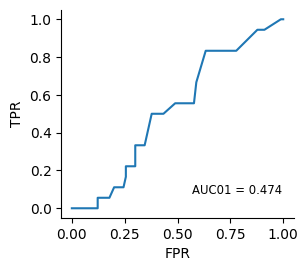

In [9]:
df_input = pd.read_csv('IMMREP23_SALPTNADLY_input.txt', sep='\t')
df_output = pd.read_csv('IMMREP23_SALPTNADLY_output.txt', sep='\t')[['id', 'AF3_iptm_pair_mean']]

df = pd.merge(df_input, df_output, on='id')

print(df.head())

fig, ax = plt.subplots(1, 1, figsize=(3, 2.7)) 

y_true = df['Label'].values
y_scores = df['AF3_iptm_pair_mean'].values

fpr, tpr, _ = roc_curve(y_true, y_scores)
auc = roc_auc_score(y_true, y_scores)
auc01 = roc_auc_score(y_true, y_scores, max_fpr=0.1)
print(auc, auc01)
line, = ax.plot(fpr, tpr)
ax.text(0.95, 0.1, f"AUC01 = {auc01:.3f}", transform=ax.transAxes,
                ha='right', va='bottom', fontsize='small')

ax.set_xlabel('FPR')
ax.set_ylabel('TPR')
sns.despine()

In [10]:
df_input = pd.read_csv('IMMREP23_SALPTNADLY_input.txt', sep='\t')
df_output = pd.read_csv('IMMREP23_SALPTNADLY_output.txt', sep='\t')[['id', 'AF3_iptm_pair_mean']]

df = pd.merge(df_input, df_output, on='id')
df = df[df['Label'] == 1]
df.to_csv('/Users/roessner/Downloads/IMMREP23_SALPTNADLY.csv', index=False)
#df = df.sort_values(by='AF3_iptm_pair_mean', ascending=False)
print(df['id'].values)

['tcr_0005' 'tcr_0007' 'tcr_0011' 'tcr_0014' 'tcr_0017' 'tcr_0022'
 'tcr_0032' 'tcr_0034' 'tcr_0041' 'tcr_0043' 'tcr_0048' 'tcr_0051'
 'tcr_0055' 'tcr_0061' 'tcr_0083' 'tcr_0089' 'tcr_0094' 'tcr_0101']
